# Datos Faltantes

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [11]:

data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
232,0.012648,0.050680,0.000261,-0.011420,0.039710,0.057245,-0.039719,0.056081,0.024055,0.032059,259.0
48,0.067136,0.050680,-0.041774,0.011544,0.002559,0.005889,0.041277,-0.039493,-0.059471,-0.021788,75.0
388,0.052606,0.050680,-0.024529,0.056301,-0.007073,-0.005072,-0.021311,-0.002592,0.026717,-0.038357,110.0
220,0.023546,0.050680,-0.039618,-0.005670,-0.048351,-0.033255,0.011824,-0.039493,-0.101640,-0.067351,78.0
351,-0.085430,0.050680,-0.040696,-0.033213,-0.081374,-0.069580,-0.006584,-0.039493,-0.057803,-0.042499,71.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0
84,0.001751,-0.044642,-0.039618,-0.100934,-0.029088,-0.030124,0.044958,-0.050195,-0.068332,-0.129483,65.0
42,-0.060003,0.050680,-0.010517,-0.014863,-0.049727,-0.023547,-0.058127,0.015858,-0.009919,-0.034215,61.0
430,-0.009147,-0.044642,-0.056863,-0.050427,0.021822,0.045345,-0.028674,0.034309,-0.009919,-0.017646,183.0
380,0.016281,-0.044642,0.026128,0.058608,-0.060735,-0.044215,-0.013948,-0.033958,-0.051404,-0.025930,52.0


In [12]:

# Simular valores faltantes
import numpy as np
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [ ]:
data.isnull().sum() 
#bmi: 44 valores faltantes
#bp: 44 valores faltantes

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
data['bmi'] = imputer.fit_transform(data[['bmi']])

In [25]:
data['bmi'].isnull().sum()  # debe dar 0

np.int64(0)

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [26]:
from sklearn.impute import KNNImputer

# Recargar datos frescos para comparar
diabetes = load_diabetes(as_frame=True)
data_knn = diabetes.data
data_knn['target'] = diabetes.target

# Volver a simular los valores faltantes
np.random.seed(42)
data_knn.loc[data_knn.sample(frac=0.1).index, 'bmi'] = np.nan
data_knn.loc[data_knn.sample(frac=0.1).index, 'bp'] = np.nan

# Aplicar KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn[['bmi', 'bp']])

# Comparar resultados
print("Media simple - bmi:", data['bmi'].mean())
print("KNN          - bmi:", data_knn['bmi'].mean())

print("Media simple - bp:", data['bp'].mean())
print("KNN          - bp:", data_knn['bp'].mean())

Media simple - bmi: -0.00020486982495319117
KNN          - bmi: 0.00021273180711015857
Media simple - bp: 0.00046537827427688047
KNN          - bp: 0.0002957652764554979


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

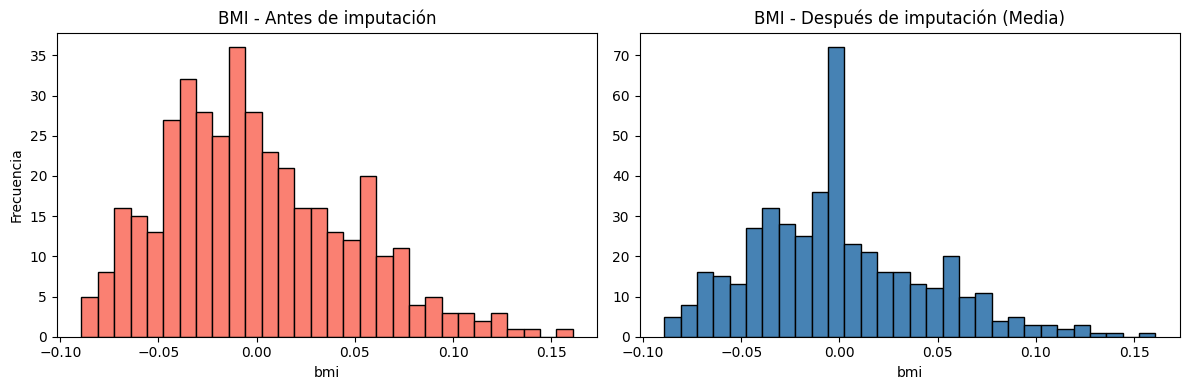

In [27]:
# Recargar datos originales con NaN para comparar
diabetes_original = load_diabetes(as_frame=True)
data_original = diabetes_original.data

np.random.seed(42)
data_original.loc[data_original.sample(frac=0.1).index, 'bmi'] = np.nan

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes de imputación
axes[0].hist(data_original['bmi'].dropna(), bins=30, color='salmon', edgecolor='black')
axes[0].set_title('BMI - Antes de imputación')
axes[0].set_xlabel('bmi')
axes[0].set_ylabel('Frecuencia')

# Después de imputación (media simple)
axes[1].hist(data['bmi'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('BMI - Después de imputación (Media)')
axes[1].set_xlabel('bmi')

plt.tight_layout()
plt.show()